# Pediatric Dataset Age Distribution Analysis

This notebook analyzes the age distribution of participants in the Bridge2AI Voice Pediatric Dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load the demographics data
df = pd.read_csv('phenotype/pediatric/pediatric_demographics.tsv', sep='\t')

# Display basic information
print(f"Total participants: {len(df)}")
print(f"Age range: {df['age'].min():.0f} - {df['age'].max():.0f} years")
print(f"\nAge statistics:")
print(df['age'].describe())

Total participants: 301
Age range: 4 - 17 years

Age statistics:
count    301.000000
mean      11.624585
std        3.417883
min        4.000000
25%        9.000000
50%       12.000000
75%       14.000000
max       17.000000
Name: age, dtype: float64


In [7]:
df[df['peds_gender_identity'] == 'Female gender identity']

,participant_id,peds_cognition,peds_country,peds_demographics_session_id,peds_edu_level,peds_first_language,peds_gender_identity,peds_hearing,peds_mobility,peds_other_edu_level,peds_other_first_language,peds_other_gender_identity,peds_primary_language,peds_race,peds_self_care,peds_vision,age
1,458172,No,Canada,c6030d0b,Some elementary school,English,Female gender identity,No,No,NaN,NaN,NaN,English,White,No,No,12.0
3,971270,No,Canada,e5887a18,Some elementary school,"Other, please specify",Female gender identity,No,No,NaN,Greek,NaN,English,White,No,No,9.0
4,216464,No,Canada,510cdad5,Some elementary school,English,Female gender identity,No,No,NaN,NaN,NaN,English,White,No,No,14.0
6,684448,No,Canada,1213f8de,Some secondary or high school education,English,Female gender identity,Yes,No,NaN,NaN,NaN,English,White,No,No,17.0
8,900559,Yes,Canada,7ea8d35a,Some elementary school,"Other, please specify",Female gender identity,No,No,Sk,Arabic and french,NaN,English,Prefer not to answer,No,No,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,635238,No,Canada,61a625d6,Some elementary school,English,Female gender identity,No,No,NaN,NaN,NaN,English,Asian,No,No,13.0
293,996675,Yes,Canada,5840f295,Some secondary or high school education,Spanish,Female gender identity,No,No,NaN,NaN,NaN,English,NaN,No,No,17.0
298,895611,Prefer not to answer,Canada,7e6dee67,Prefer not to answer,"Other, please specify",Female gender identity,Prefer not to answer,Prefer not to answer,NaN,NaN,NaN,"Other, please specify",NaN,Prefer not to answer,Prefer not to answer,14.0
299,331147,No,Canada,a676d62c,Some elementary school,Punjabi,Female gender identity,No,No,NaN,NaN,NaN,English,Asian,No,No,11.0


In [27]:
df[df['age'] <= 8 ]['participant_id'].nunique()

68

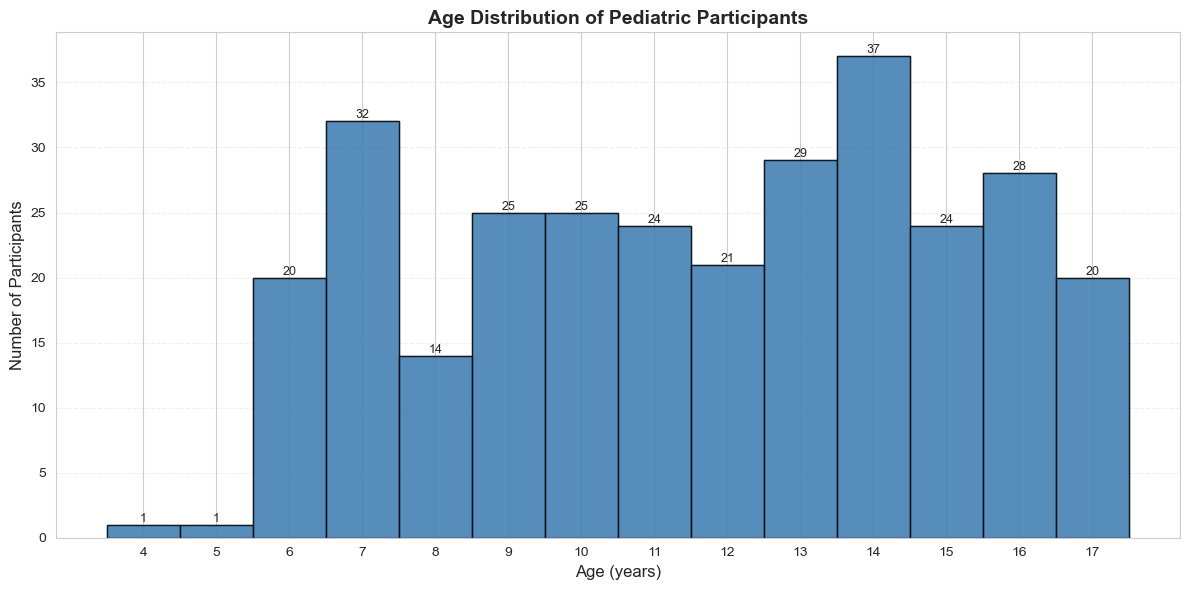

In [28]:
# Create histogram of age distribution
plt.figure(figsize=(12, 6))

# Create histogram with bins for each age
ages = df['age'].dropna()
bins = np.arange(ages.min() - 0.5, ages.max() + 1.5, 1)

plt.hist(ages, bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Number of Participants', fontsize=12)
plt.title('Age Distribution of Pediatric Participants', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(range(int(ages.min()), int(ages.max()) + 1))

# Add value labels on top of bars
counts, bins_edges, patches = plt.gca().hist(ages, bins=bins, edgecolor='black', alpha=0.7, color='steelblue')
for i, count in enumerate(counts):
    if count > 0:
        plt.text(bins_edges[i] + 0.5, count, str(int(count)), 
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

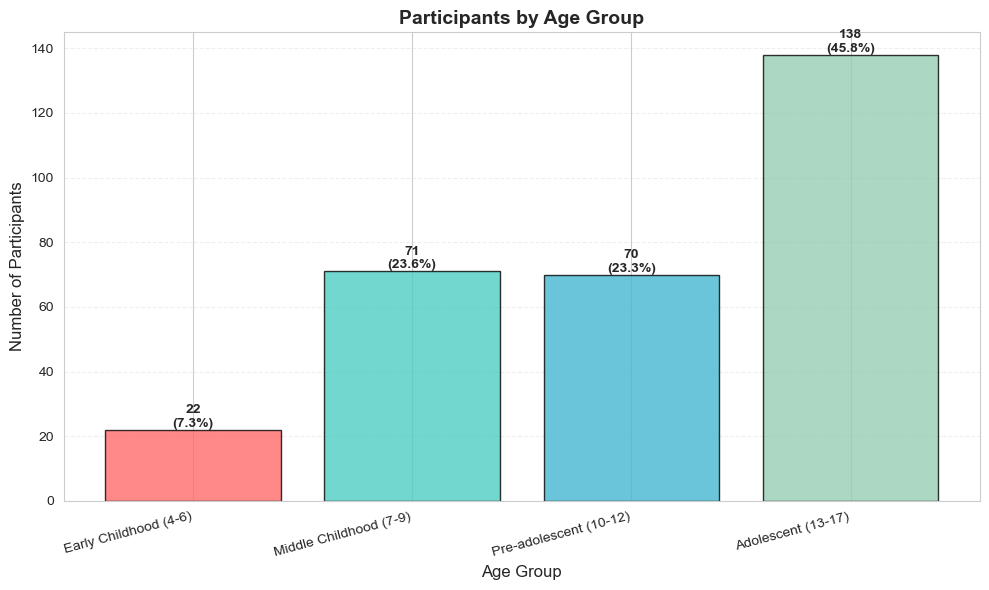

In [29]:
# Create grouped age distribution
age_groups = pd.cut(df['age'], 
                    bins=[0, 6, 9, 12, 18], 
                    labels=['Early Childhood (4-6)', 'Middle Childhood (7-9)', 
                           'Pre-adolescent (10-12)', 'Adolescent (13-17)'],
                    include_lowest=True)

age_group_counts = age_groups.value_counts().sort_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(age_group_counts)), age_group_counts.values, 
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], 
               edgecolor='black', alpha=0.8)

plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Number of Participants', fontsize=12)
plt.title('Participants by Age Group', fontsize=14, fontweight='bold')
plt.xticks(range(len(age_group_counts)), age_group_counts.index, rotation=15, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels and percentages
total = age_group_counts.sum()
for i, (bar, count) in enumerate(zip(bars, age_group_counts.values)):
    percentage = (count / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2, count, 
            f'{int(count)}\n({percentage:.1f}%)', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [30]:
# Detailed age breakdown table
age_counts = df['age'].value_counts().sort_index()
age_breakdown = pd.DataFrame({
    'Age': age_counts.index,
    'Count': age_counts.values,
    'Percentage': (age_counts.values / len(df) * 100).round(1)
})

print("\nDetailed Age Breakdown:")
print(age_breakdown.to_string(index=False))


Detailed Age Breakdown:
 Age  Count  Percentage
 4.0      1         0.3
 5.0      1         0.3
 6.0     20         6.6
 7.0     32        10.6
 8.0     14         4.7
 9.0     25         8.3
10.0     25         8.3
11.0     24         8.0
12.0     21         7.0
13.0     29         9.6
14.0     37        12.3
15.0     24         8.0
16.0     28         9.3
17.0     20         6.6


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

In [8]:
# Load the medical conditions data
df = pd.read_csv('phenotype/pediatric/pediatric_medical_conditions.tsv', sep='\t')

print(f"Total records: {len(df)}")
print(f"Number of columns: {len(df.columns)}")
print(f"\nColumn names:")
print(df.columns.tolist())

Total records: 305
Number of columns: 50

Column names:
['participant_id', 'peds_mc_a_therapy', 'peds_mc_adenoidectomy', 'peds_mc_allergies', 'peds_mc_breathing_conditions', 'peds_mc_chronic_medical_condition', 'peds_mc_completed_at', 'peds_mc_conditions', 'peds_mc_dif_swallowing', 'peds_mc_duration', 'peds_mc_ear_inf_ant_py', 'peds_mc_epistaxis', 'peds_mc_etp', 'peds_mc_eval_voice_swal_c', 'peds_mc_fr_inf_tons', 'peds_mc_fr_v_f', 'peds_mc_ft', 'peds_mc_genetic_syndromes', 'peds_mc_hearing_loss', 'peds_mc_hl', 'peds_mc_hospitalized', 'peds_mc_hw_voice_2_w', 'peds_mc_l2w', 'peds_mc_lingual_tonsillectomy', 'peds_mc_meds', 'peds_mc_nasal_fractures', 'peds_mc_neck_mass_branchial_cleft_cyst_surgery', 'peds_mc_neck_mass_dermoid_cyst_surgery', 'peds_mc_neck_mass_enlarged_lymph_node_surgery', 'peds_mc_neck_mass_hyroid_nodule_or_cancer_surgery', 'peds_mc_neck_mass_other', 'peds_mc_neck_mass_thyroglossal_duct_cyst_surgery', 'peds_mc_neurological_disorders', 'peds_mc_neurological_disorders_specif

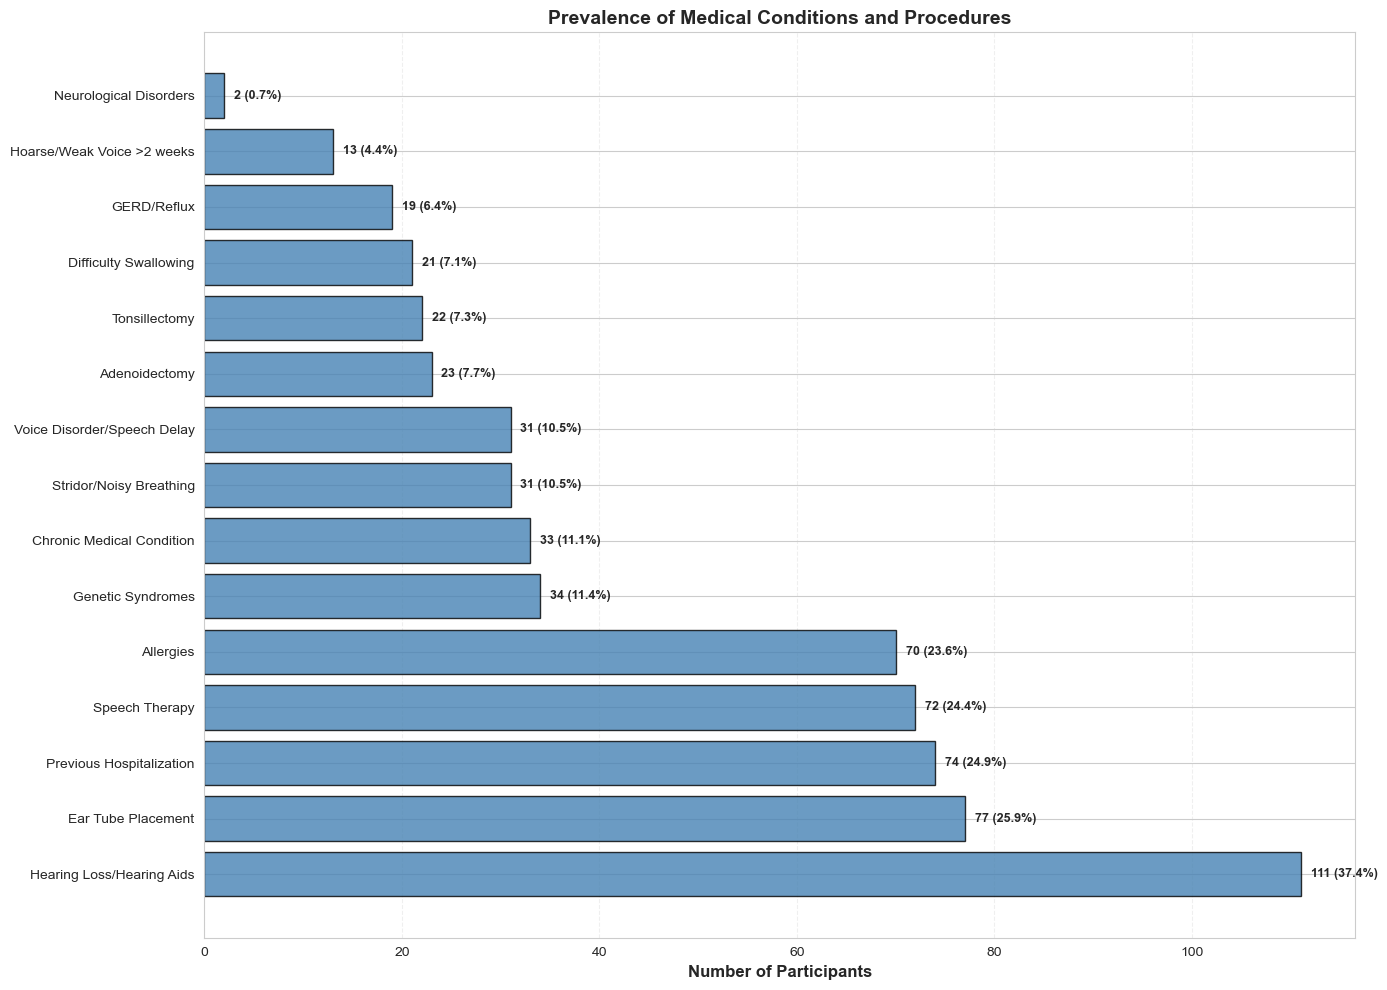

In [33]:
# Key yes/no medical condition columns
yes_no_conditions = {
    'peds_mc_a_therapy': 'Speech Therapy',
    'peds_mc_allergies': 'Allergies',
    'peds_mc_chronic_medical_condition': 'Chronic Medical Condition',
    'peds_mc_dif_swallowing': 'Difficulty Swallowing',
    'peds_mc_hl': 'Hearing Loss/Hearing Aids',
    'peds_mc_hospitalized': 'Previous Hospitalization',
    'peds_mc_hw_voice_2_w': 'Hoarse/Weak Voice >2 weeks',
    'peds_mc_genetic_syndromes': 'Genetic Syndromes',
    'peds_mc_neurological_disorders': 'Neurological Disorders',
    'peds_mc_reflux': 'GERD/Reflux',
    'peds_mc_stridor': 'Stridor/Noisy Breathing',
    'peds_mc_v_dis': 'Voice Disorder/Speech Delay',
    'peds_mc_tonsillectomy': 'Tonsillectomy',
    'peds_mc_adenoidectomy': 'Adenoidectomy',
    'peds_mc_etp': 'Ear Tube Placement',
}

# Calculate percentages
condition_counts = {}
for col, label in yes_no_conditions.items():
    if col in df.columns:
        yes_count = (df[col] == 'Yes').sum()
        total_valid = df[col].notna().sum()
        if total_valid > 0:
            percentage = (yes_count / total_valid) * 100
            condition_counts[label] = {'count': yes_count, 'percentage': percentage}

# Sort by count
sorted_conditions = sorted(condition_counts.items(), key=lambda x: x[1]['count'], reverse=True)

# Create bar plot
plt.figure(figsize=(14, 10))
labels = [item[0] for item in sorted_conditions]
counts = [item[1]['count'] for item in sorted_conditions]
percentages = [item[1]['percentage'] for item in sorted_conditions]

bars = plt.barh(range(len(labels)), counts, color='steelblue', edgecolor='black', alpha=0.8)
plt.yticks(range(len(labels)), labels)
plt.xlabel('Number of Participants', fontsize=12, fontweight='bold')
plt.title('Prevalence of Medical Conditions and Procedures', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (bar, count, pct) in enumerate(zip(bars, counts, percentages)):
    plt.text(count + 1, bar.get_y() + bar.get_height()/2, 
             f'{int(count)} ({pct:.1f}%)', 
             va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
df['peds_mc_neurological_disorders_specified'].unique()

<ArrowStringArray>
[nan, 'N/a', 'Cmt', 'Myotonia congenita']
Length: 4, dtype: str

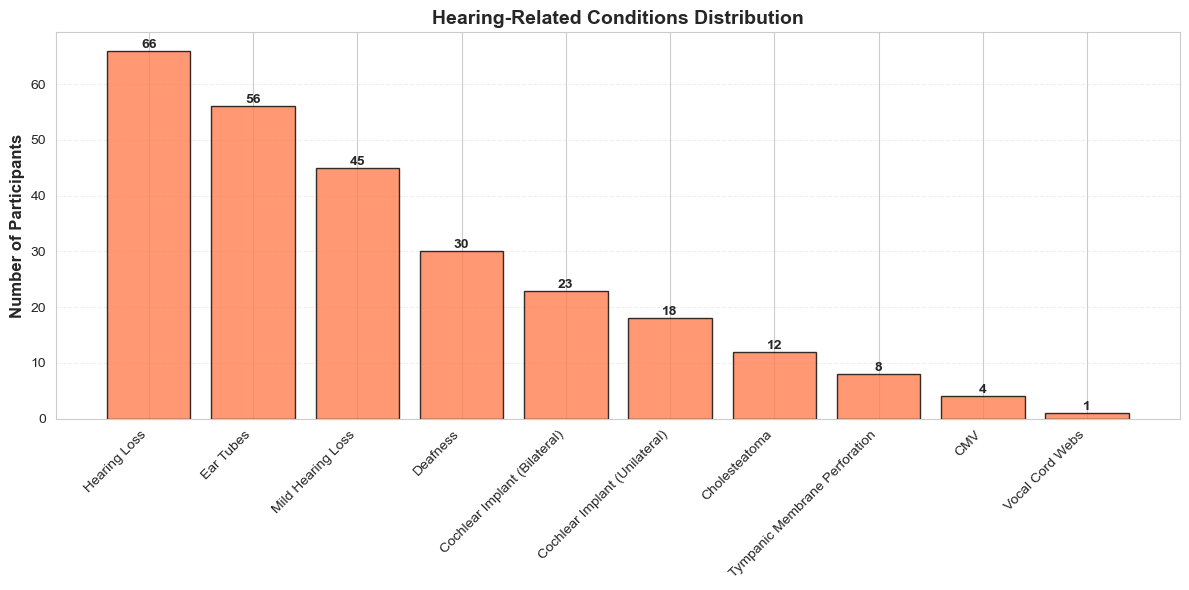

In [34]:
# Parse hearing loss conditions (multi-select field)
hearing_conditions = []
for val in df['peds_mc_hearing_loss'].dropna():
    if isinstance(val, str) and val.strip():
        hearing_conditions.extend([item.strip() for item in val.split(',')])

hearing_counter = Counter(hearing_conditions)

if hearing_counter:
    # Readable labels
    hearing_labels = {
        'hearing loss': 'Hearing Loss',
        'mild hearing loss': 'Mild Hearing Loss',
        'deafness': 'Deafness',
        'cholesteatoma': 'Cholesteatoma',
        'ear tubes': 'Ear Tubes',
        'cochlear implantation bilateral': 'Cochlear Implant (Bilateral)',
        'cochlear implantation unilateral': 'Cochlear Implant (Unilateral)',
        'tympanic membrane perforation': 'Tympanic Membrane Perforation',
        'cmv': 'CMV',
        'vocal cord webs': 'Vocal Cord Webs'
    }
    
    hearing_data = [(hearing_labels.get(k, k.title()), v) for k, v in hearing_counter.most_common()]
    hearing_data = sorted(hearing_data, key=lambda x: x[1], reverse=True)
    
    plt.figure(figsize=(12, 6))
    labels_h = [item[0] for item in hearing_data]
    counts_h = [item[1] for item in hearing_data]
    
    bars = plt.bar(range(len(labels_h)), counts_h, color='coral', edgecolor='black', alpha=0.8)
    plt.xticks(range(len(labels_h)), labels_h, rotation=45, ha='right')
    plt.ylabel('Number of Participants', fontsize=12, fontweight='bold')
    plt.title('Hearing-Related Conditions Distribution', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar, count in zip(bars, counts_h):
        plt.text(bar.get_x() + bar.get_width()/2, count, str(count), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No hearing loss data found")

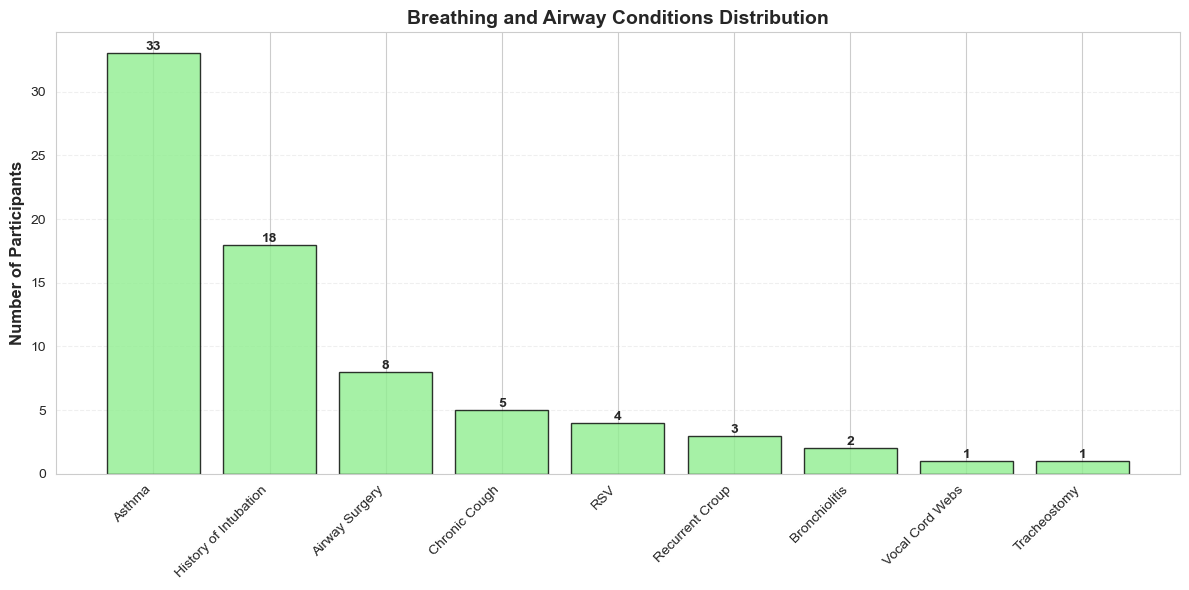

In [35]:
# Parse breathing conditions (multi-select field)
breathing_conditions = []
for val in df['peds_mc_breathing_conditions'].dropna():
    if isinstance(val, str) and val.strip():
        breathing_conditions.extend([item.strip() for item in val.split(',')])

breathing_counter = Counter(breathing_conditions)

if breathing_counter:
    # Readable labels
    breathing_labels = {
        'asthma': 'Asthma',
        'recurrent croup': 'Recurrent Croup',
        'bronchiolitis': 'Bronchiolitis',
        'rsv': 'RSV',
        'chronic cough': 'Chronic Cough',
        'subglottic stenosis': 'Subglottic Stenosis',
        'vocal cord webs': 'Vocal Cord Webs',
        'airway surgery': 'Airway Surgery',
        'intubated': 'History of Intubation',
        'tracheostomy': 'Tracheostomy'
    }
    
    breathing_data = [(breathing_labels.get(k, k.title()), v) for k, v in breathing_counter.most_common()]
    breathing_data = sorted(breathing_data, key=lambda x: x[1], reverse=True)
    
    plt.figure(figsize=(12, 6))
    labels_b = [item[0] for item in breathing_data]
    counts_b = [item[1] for item in breathing_data]
    
    bars = plt.bar(range(len(labels_b)), counts_b, color='lightgreen', edgecolor='black', alpha=0.8)
    plt.xticks(range(len(labels_b)), labels_b, rotation=45, ha='right')
    plt.ylabel('Number of Participants', fontsize=12, fontweight='bold')
    plt.title('Breathing and Airway Conditions Distribution', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar, count in zip(bars, counts_b):
        plt.text(bar.get_x() + bar.get_width()/2, count, str(count), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No breathing conditions data found")

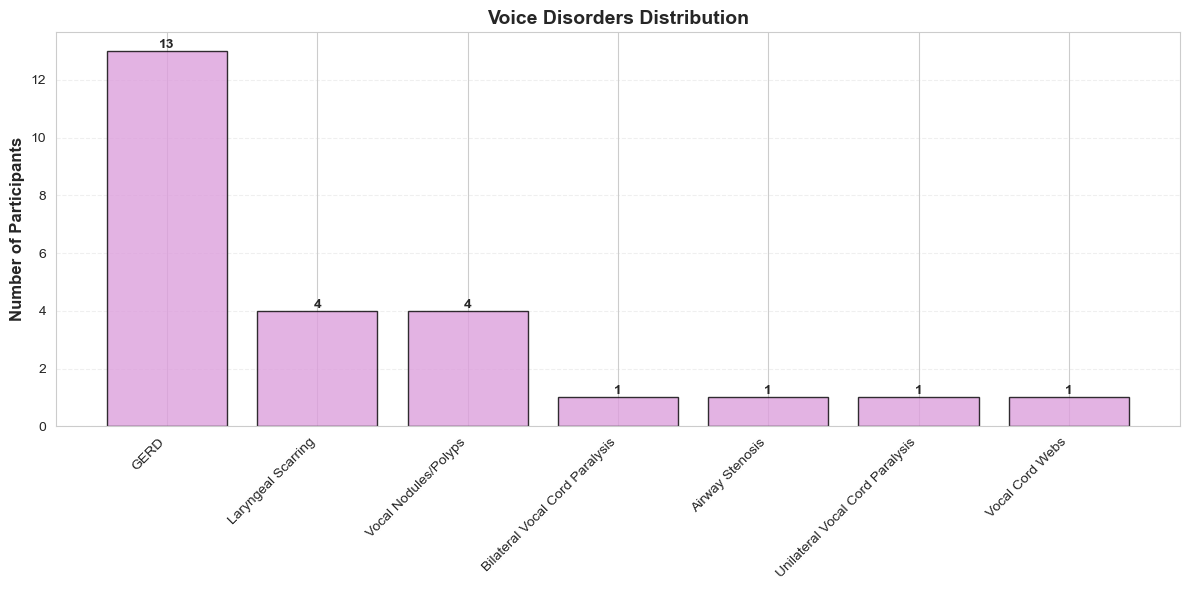

In [36]:
# Parse voice disorders (multi-select field)
voice_disorders = []
for val in df['peds_mc_voice_disorders'].dropna():
    if isinstance(val, str) and val.strip():
        voice_disorders.extend([item.strip() for item in val.split(',')])

voice_counter = Counter(voice_disorders)

if voice_counter:
    # Readable labels
    voice_labels = {
        'vocal nodules or polyps': 'Vocal Nodules/Polyps',
        'unilateral vocal cord paralysis': 'Unilateral Vocal Cord Paralysis',
        'bilateral vocal cord paralysis': 'Bilateral Vocal Cord Paralysis',
        'acid reflux disease': 'GERD',
        'scarring': 'Laryngeal Scarring',
        'airway stenosis': 'Airway Stenosis',
        'vocal cord webs': 'Vocal Cord Webs'
    }
    
    voice_data = [(voice_labels.get(k, k.title()), v) for k, v in voice_counter.most_common()]
    voice_data = sorted(voice_data, key=lambda x: x[1], reverse=True)
    
    plt.figure(figsize=(12, 6))
    labels_v = [item[0] for item in voice_data]
    counts_v = [item[1] for item in voice_data]
    
    bars = plt.bar(range(len(labels_v)), counts_v, color='plum', edgecolor='black', alpha=0.8)
    plt.xticks(range(len(labels_v)), labels_v, rotation=45, ha='right')
    plt.ylabel('Number of Participants', fontsize=12, fontweight='bold')
    plt.title('Voice Disorders Distribution', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar, count in zip(bars, counts_v):
        plt.text(bar.get_x() + bar.get_width()/2, count, str(count), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No voice disorders data found")

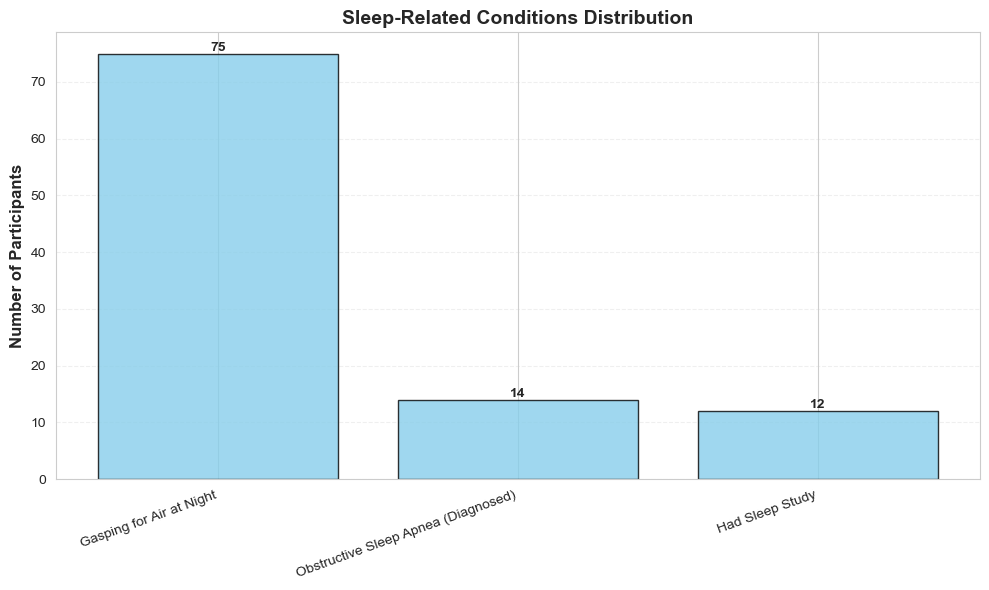

In [37]:
# Parse snoring/apnea conditions (multi-select field)
sleep_conditions = []
for val in df['peds_mc_snoring_apnea'].dropna():
    if isinstance(val, str) and val.strip():
        sleep_conditions.extend([item.strip() for item in val.split(',')])

sleep_counter = Counter(sleep_conditions)

if sleep_counter:
    # Readable labels
    sleep_labels = {
        'snoring': 'Snoring',
        'gasping': 'Gasping for Air at Night',
        'obstructive sleep apnea': 'Obstructive Sleep Apnea (Diagnosed)',
        'had sleep study': 'Had Sleep Study'
    }
    
    sleep_data = [(sleep_labels.get(k, k.title()), v) for k, v in sleep_counter.most_common()]
    sleep_data = sorted(sleep_data, key=lambda x: x[1], reverse=True)
    
    plt.figure(figsize=(10, 6))
    labels_s = [item[0] for item in sleep_data]
    counts_s = [item[1] for item in sleep_data]
    
    bars = plt.bar(range(len(labels_s)), counts_s, color='skyblue', edgecolor='black', alpha=0.8)
    plt.xticks(range(len(labels_s)), labels_s, rotation=20, ha='right')
    plt.ylabel('Number of Participants', fontsize=12, fontweight='bold')
    plt.title('Sleep-Related Conditions Distribution', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar, count in zip(bars, counts_s):
        plt.text(bar.get_x() + bar.get_width()/2, count, str(count), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No sleep-related data found")

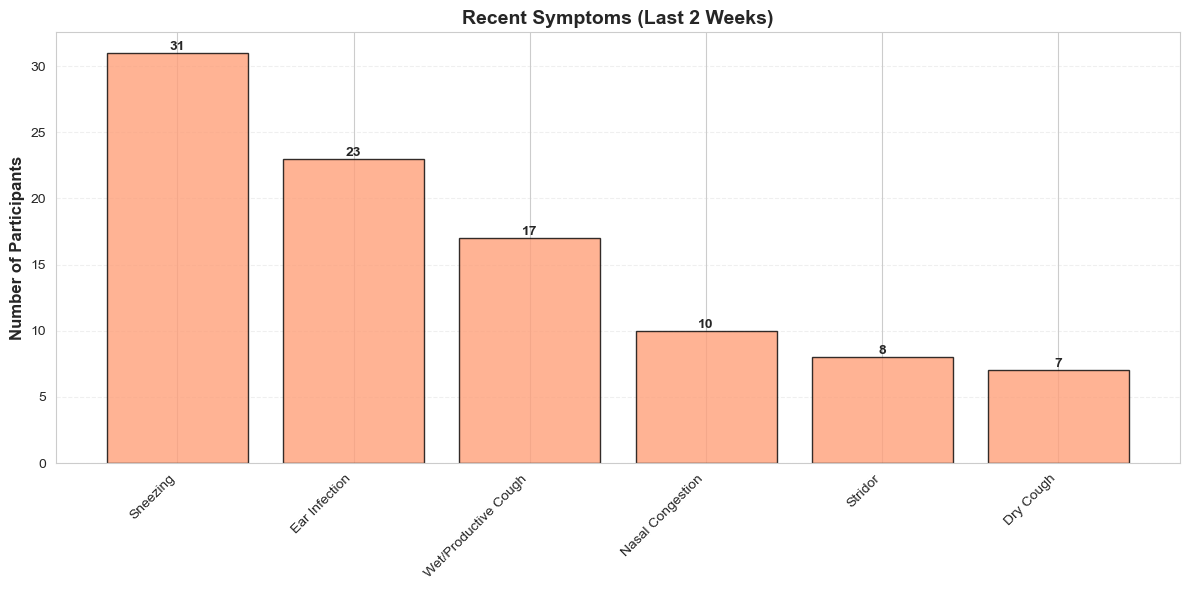

In [38]:
# Parse recent symptoms (multi-select field)
recent_symptoms = []
for val in df['peds_mc_l2w'].dropna():
    if isinstance(val, str) and val.strip():
        recent_symptoms.extend([item.strip() for item in val.split(',')])

recent_counter = Counter(recent_symptoms)

if recent_counter:
    # Readable labels
    recent_labels = {
        'wheezing or trouble breathing': 'Wheezing/Trouble Breathing',
        'dry cough': 'Dry Cough',
        'wet productive cough': 'Wet/Productive Cough',
        'nasal congestion': 'Nasal Congestion',
        'sneezing': 'Sneezing',
        'ear infection': 'Ear Infection',
        'stridor': 'Stridor',
        'croup': 'Croup',
        'sorethroat or tonsillitis': 'Sore Throat/Tonsillitis'
    }
    
    recent_data = [(recent_labels.get(k, k.title()), v) for k, v in recent_counter.most_common()]
    recent_data = sorted(recent_data, key=lambda x: x[1], reverse=True)
    
    plt.figure(figsize=(12, 6))
    labels_r = [item[0] for item in recent_data]
    counts_r = [item[1] for item in recent_data]
    
    bars = plt.bar(range(len(labels_r)), counts_r, color='lightsalmon', edgecolor='black', alpha=0.8)
    plt.xticks(range(len(labels_r)), labels_r, rotation=45, ha='right')
    plt.ylabel('Number of Participants', fontsize=12, fontweight='bold')
    plt.title('Recent Symptoms (Last 2 Weeks)', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels
    for bar, count in zip(bars, counts_r):
        plt.text(bar.get_x() + bar.get_width()/2, count, str(count), 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("No recent symptoms data found")

In [39]:
# Load acoustic tasks data
tasks_df = pd.read_csv('phenotype/task/acoustic_task.tsv', sep='\t')

print(f"Total task records: {len(tasks_df)}")
print(f"Unique participants: {tasks_df['participant_id'].nunique()}")
print(f"\nColumns:")
print(tasks_df.columns.tolist())

Total task records: 3798
Unique participants: 300

Columns:
['participant_id', 'acoustic_task_cohort', 'acoustic_task_duration', 'acoustic_task_id', 'acoustic_task_name', 'acoustic_task_session_id', 'acoustic_task_status']


## Acoustic Task Analysis

Analyzing the types of voice recording activities performed by participants.

Tasks per participant statistics:
count    300.000000
mean      12.660000
std        0.521511
min       10.000000
25%       12.000000
50%       13.000000
75%       13.000000
max       13.000000
dtype: float64


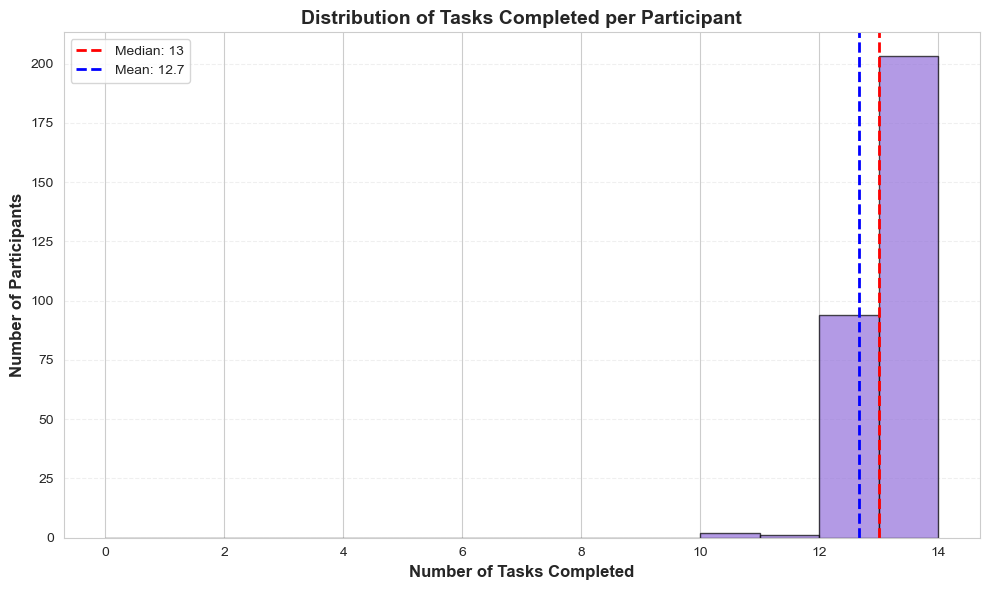

In [40]:
# Number of tasks per participant
tasks_per_participant = tasks_df.groupby('participant_id').size()

print(f"Tasks per participant statistics:")
print(tasks_per_participant.describe())

plt.figure(figsize=(10, 6))
plt.hist(tasks_per_participant, bins=range(0, int(tasks_per_participant.max()) + 2), 
         edgecolor='black', alpha=0.7, color='mediumpurple')
plt.xlabel('Number of Tasks Completed', fontsize=12, fontweight='bold')
plt.ylabel('Number of Participants', fontsize=12, fontweight='bold')
plt.title('Distribution of Tasks Completed per Participant', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add median and mean lines
median = tasks_per_participant.median()
mean = tasks_per_participant.mean()
plt.axvline(median, color='red', linestyle='--', linewidth=2, label=f'Median: {median:.0f}')
plt.axvline(mean, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mean:.1f}')
plt.legend()

plt.tight_layout()
plt.show()

Task Completion Status:
acoustic_task_status
Completed    3798
Name: count, dtype: int64

Completion rate: 100.0%


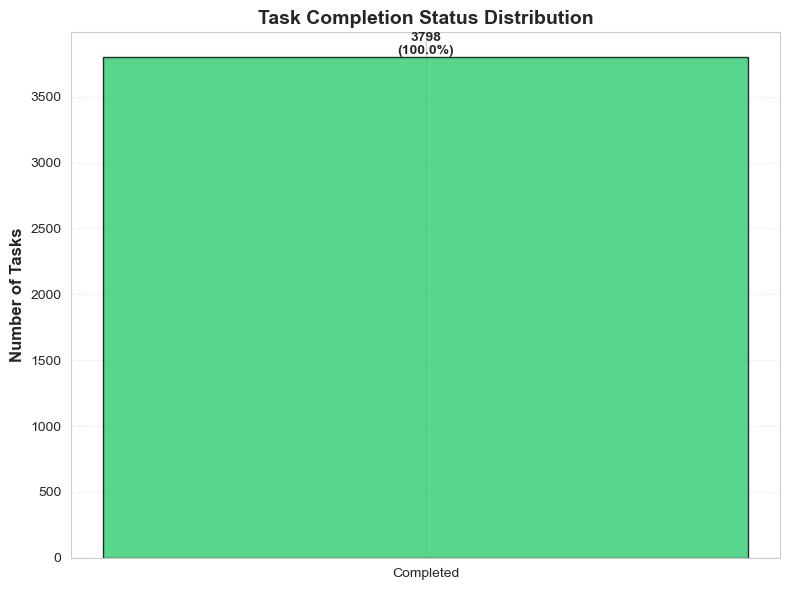

In [41]:
# Task completion rate analysis
completion_status = tasks_df['acoustic_task_status'].value_counts()

print("Task Completion Status:")
print(completion_status)
print(f"\nCompletion rate: {(completion_status.get('Completed', 0) / len(tasks_df) * 100):.1f}%")

# Visualize completion status
plt.figure(figsize=(8, 6))
colors_status = {'Completed': '#2ECC71', 'Failed': '#E74C3C', 'In Progress': '#F39C12'}
status_colors = [colors_status.get(status, 'gray') for status in completion_status.index]

bars = plt.bar(range(len(completion_status)), completion_status.values, 
               color=status_colors, edgecolor='black', alpha=0.8)
plt.xticks(range(len(completion_status)), completion_status.index)
plt.ylabel('Number of Tasks', fontsize=12, fontweight='bold')
plt.title('Task Completion Status Distribution', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels and percentages
for bar, status, count in zip(bars, completion_status.index, completion_status.values):
    percentage = (count / len(tasks_df)) * 100
    plt.text(bar.get_x() + bar.get_width()/2, count, 
             f'{count}\n({percentage:.1f}%)', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [42]:
# Analyze average task duration by task type
avg_durations = tasks_df.groupby('acoustic_task_name')['acoustic_task_duration'].mean().sort_values(ascending=False)

# Create readable labels
duration_data = [(task_labels.get(name, name.title()), duration) 
                 for name, duration in avg_durations.items()]

plt.figure(figsize=(14, 8))
labels_d = [item[0] for item in duration_data]
durations = [item[1] for item in duration_data]

bars = plt.barh(range(len(labels_d)), durations, color='darkorange', edgecolor='black', alpha=0.8)
plt.yticks(range(len(labels_d)), labels_d)
plt.xlabel('Average Duration (seconds)', fontsize=12, fontweight='bold')
plt.title('Average Duration by Task Type', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for bar, duration in zip(bars, durations):
    plt.text(duration + 1, bar.get_y() + bar.get_height()/2, 
             f'{duration:.1f}s', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

NameError: name 'task_labels' is not defined

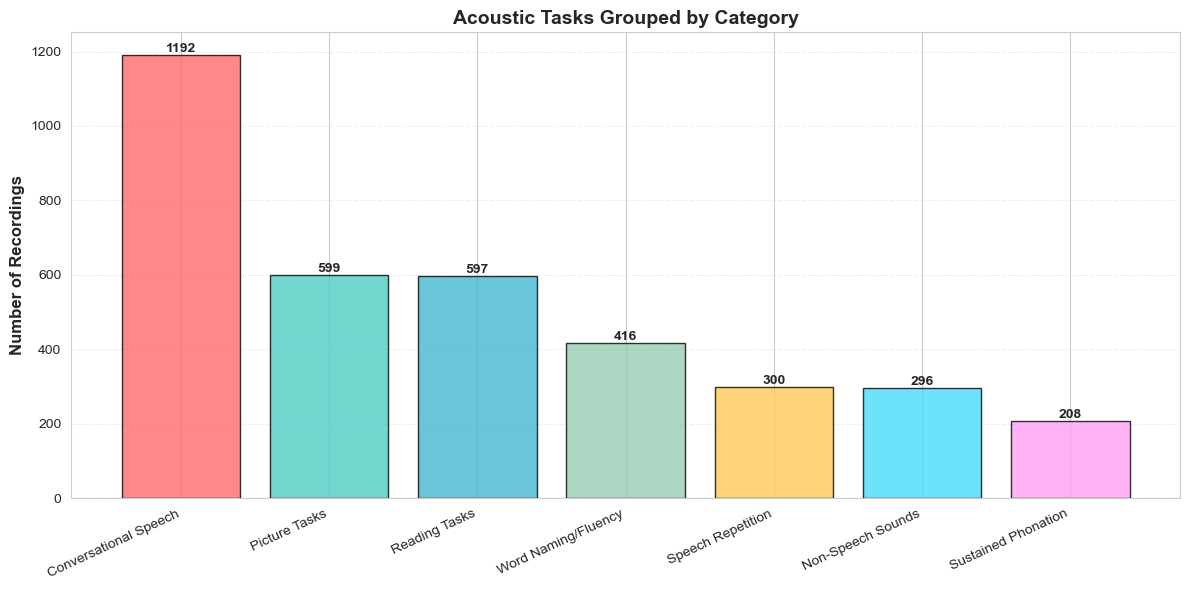


Task Category Summary:
Conversational Speech: 1192 recordings (31.4%)
Picture Tasks: 599 recordings (15.8%)
Reading Tasks: 597 recordings (15.7%)
Word Naming/Fluency: 416 recordings (11.0%)
Speech Repetition: 300 recordings (7.9%)
Non-Speech Sounds: 296 recordings (7.8%)
Sustained Phonation: 208 recordings (5.5%)


In [ ]:
# Categorize tasks by type
task_categories = {
    'Conversational Speech': ['ready-for-school', 'favorite-show-movie-game', 'favorite-food', 'outside-of-school'],
    'Word Naming/Fluency': ['naming-animals', 'naming-food'],
    'Sustained Phonation': ['long-sounds'],
    'Non-Speech Sounds': ['silly-sounds'],
    'Picture Tasks': ['picture', 'picture-description'],
    'Reading Tasks': ['sentence', 'passage'],
    'Speech Repetition': ['repeat-words']
}a  

# Count tasks by category
category_counts = {}
for category, task_names in task_categories.items():
    count = tasks_df[tasks_df['acoustic_task_name'].isin(task_names)].shape[0]
    category_counts[category] = count

# Sort by count
sorted_categories = sorted(category_counts.items(), key=lambda x: x[1], reverse=True)

# Visualize
plt.figure(figsize=(12, 6))
categories = [item[0] for item in sorted_categories]
cat_counts = [item[1] for item in sorted_categories]

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#48DBFB', '#FF9FF3']
bars = plt.bar(range(len(categories)), cat_counts, color=colors[:len(categories)], 
               edgecolor='black', alpha=0.8)

plt.xticks(range(len(categories)), categories, rotation=25, ha='right')
plt.ylabel('Number of Recordings', fontsize=12, fontweight='bold')
plt.title('Acoustic Tasks Grouped by Category', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bar, count in zip(bars, cat_counts):
    plt.text(bar.get_x() + bar.get_width()/2, count, str(count), 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("\nTask Category Summary:")
for category, count in sorted_categories:
    percentage = (count / len(tasks_df)) * 100
    print(f"{category}: {count} recordings ({percentage:.1f}%)")

In [44]:
# Visualize task type distribution
plt.figure(figsize=(14, 8))

# Create readable labels
task_labels = {
    'ready-for-school': 'Ready for School',
    'favorite-show-movie-game': 'Favorite Show/Movie/Game',
    'favorite-food': 'Favorite Food',
    'outside-of-school': 'Outside of School',
    'naming-animals': 'Naming Animals',
    'naming-food': 'Naming Food',
    'long-sounds': 'Long Sounds (Vowels)',
    'silly-sounds': 'Silly Sounds',
    'picture': 'Picture Naming',
    'picture-description': 'Picture Description',
    'sentence': 'Sentence Reading',
    'passage': 'Passage Reading',
    'repeat-words': 'Repeat Words'
}

# Map task names to readable labels
task_data = [(task_labels.get(name, name.title()), count) 
             for name, count in task_counts.items()]
task_data = sorted(task_data, key=lambda x: x[1], reverse=True)

labels = [item[0] for item in task_data]
counts = [item[1] for item in task_data]

bars = plt.barh(range(len(labels)), counts, color='teal', edgecolor='black', alpha=0.8)
plt.yticks(range(len(labels)), labels)
plt.xlabel('Number of Recordings', fontsize=12, fontweight='bold')
plt.title('Distribution of Acoustic Task Types', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for bar, count in zip(bars, counts):
    plt.text(count + 2, bar.get_y() + bar.get_height()/2, 
             str(count), va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

NameError: name 'task_counts' is not defined

<Figure size 1400x800 with 0 Axes>

In [45]:
# Count task types
task_counts = tasks_df['acoustic_task_name'].value_counts()

print("Task Type Distribution:")
print(task_counts)
print(f"\nTotal unique task types: {len(task_counts)}")

Task Type Distribution:
acoustic_task_name
picture                     300
repeat-words                300
picture-description         299
sentence                    299
ready-for-school            298
favorite-show-movie-game    298
favorite-food               298
outside-of-school           298
passage                     298
silly-sounds                296
naming-animals              208
naming-food                 208
long-sounds                 208
noisy-sounds                 92
role-namings                 90
123s                          2
pictures-and-doors            2
days                          2
months                        2
Name: count, dtype: int64

Total unique task types: 19
